## Dataset_description : Predictive Maintenance Dataset

This dataset contains time-series operational data collected from industrial machines,
designed to support predictive maintenance and failure prediction tasks.

The dataset includes 24,042 records and 15 features, representing machine sensor readings,
operational conditions, and maintenance-related information.

Each row corresponds to a machine observation recorded at a specific timestamp.
The data reflects real-world conditions, including missing values in several sensor columns.

The dataset supports multiple analytical use cases such as:
- Failure prediction (classification)
- Remaining useful life estimation (regression)
- Anomaly detection
- Maintenance optimization

It includes both input features (sensor and operational data) and target variables
related to machine failure and maintenance outcomes.

## Data Dictionary

| Column Name              | Description                                                                 |
|-------------------------|-----------------------------------------------------------------------------|
| timestamp               | Date and time of the machine observation                                   |
| machine_id              | Unique identifier for each machine                                         |
| machine_type            | Type or category of the machine                                            |
| vibration_rms           | Root Mean Square (RMS) of vibration indicating mechanical condition        |
| temperature_motor       | Motor temperature measured in degrees Celsius                              |
| current_phase_avg       | Average electrical current across phases (machine load indicator)          |
| pressure_level          | Pressure measurement within the system                                     |
| rpm                     | Rotational speed in revolutions per minute                                 |
| operating_mode          | Current operating state of the machine (e.g., idle, active)                |
| hours_since_maintenance | Number of hours since last maintenance activity                            |
| ambient_temp            | Ambient environmental temperature                                          |
| rul_hours               | Remaining Useful Life (RUL) in hours before expected failure               |
| failure_within_24h      | Indicates whether a failure occurs within 24 hours (1 = yes, 0 = no)       |
| failure_type            | Type or category of machine failure                                        |
| estimated_repair_cost   | Estimated cost required to repair the machine after failure                |

## Show some data info

In [14]:
# from google.colab import files
# uploaded = files.upload()

In [15]:
import pandas as pd
df = pd.read_csv("predictive_maintenance_v3.csv")
df.head()

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,1/1/2024 0:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,1/1/2024 0:03,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,1/1/2024 0:21,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,1/1/2024 0:45,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,1/1/2024 0:54,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


In [16]:
df.shape

(24042, 15)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                24042 non-null  object 
 1   machine_id               24042 non-null  int64  
 2   machine_type             24042 non-null  object 
 3   vibration_rms            23042 non-null  float64
 4   temperature_motor        23208 non-null  float64
 5   current_phase_avg        23311 non-null  float64
 6   pressure_level           23118 non-null  float64
 7   rpm                      23509 non-null  float64
 8   operating_mode           24042 non-null  object 
 9   hours_since_maintenance  24042 non-null  float64
 10  ambient_temp             24042 non-null  float64
 11  rul_hours                24042 non-null  float64
 12  failure_within_24h       24042 non-null  int64  
 13  failure_type             24042 non-null  object 
 14  estimated_repair_cost 

In [18]:
df.describe()

,machine_id,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,estimated_repair_cost
count,24042.000000,23042.000000,23208.000000,23311.000000,23118.000000,23509.000000,24042.000000,24042.000000,24042.000000,24042.000000,24042.000000
mean,10.505033,1.623667,51.404295,8.823829,59.012233,1144.849317,172.630624,12.996398,27.812510,0.148074,608.870144
std,5.746455,1.081061,12.519279,5.366391,38.723271,912.670971,150.722469,2.883994,26.393801,0.355181,1566.793887
min,1.000000,0.350000,28.000000,2.200000,10.100000,124.100000,0.000000,8.000000,0.500000,0.000000,0.000000
25%,6.000000,0.820000,42.610000,4.630000,22.700000,489.400000,42.870000,10.500000,0.500000,0.000000,0.000000
50%,10.000000,1.270000,50.060000,6.430000,46.300000,856.000000,121.610000,13.000000,22.570000,0.000000,0.000000
75%,15.000000,2.270000,59.962500,13.120000,94.700000,1676.000000,295.575000,15.500000,46.410000,0.000000,0.000000
max,20.000000,10.000000,95.000000,35.000000,206.500000,4098.800000,575.630000,18.000000,98.340000,1.000000,7995.000000


## Fixing Data

In [19]:
"""
We have a timestamp column that contains both date and time.
We need to split it into two separate columns: one for the date and one for the time,
ensuring that each column has the appropriate and correct data type for further analysis.
"""

df['timestamp'] = pd.to_datetime(df['timestamp'])

df['date'] = df['timestamp'].dt.date
df['time'] = df['timestamp'].dt.time

In [20]:
df['machine_id'] = df['machine_id'].astype('object')

### Check Nulls

In [21]:
df.isnull().sum().sort_values(ascending=False)

,0
vibration_rms,1000
pressure_level,924
temperature_motor,834
current_phase_avg,731
rpm,533
timestamp,0
machine_type,0
machine_id,0
operating_mode,0
hours_since_maintenance,0


In [22]:
# Filling missing values in numerical columns with 0 to handle nulls and ensure consistency for analysis
df.fillna(0, inplace=True)

In [23]:
# Check duplicates
df.duplicated().sum()


np.int64(0)

## Check Outliers

In [24]:
def detect_outliers_iqr(df, cols):
    df = df.copy()
    outlier_mask = pd.DataFrame(False, index=df.index, columns=cols)

    for col in cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        outlier_mask[col] = (
            (df[col] < Q1 - 1.5 * IQR) |
            (df[col] > Q3 + 1.5 * IQR)
        )

    return outlier_mask

In [25]:
num_cols = ['vibration_rms', 'pressure_level', 'temperature_motor', 'current_phase_avg', 'rpm']

outliers = detect_outliers_iqr(df, num_cols)

In [26]:
outliers.sum()

,0
vibration_rms,463
pressure_level,3
temperature_motor,1037
current_phase_avg,155
rpm,353


In [27]:
df[outliers.any(axis=1)]

# Outliers detection using the IQR method across numerical columns.
# The summary shows the number of detected outliers per feature,
# and the filtered dataset highlights rows where at least one feature
# lies outside the acceptable range (1.5 * IQR rule).
# A total of 1787 rows were flagged as containing outliers for further analysis.

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost,date,time
37,2024-01-01 10:12:00,1,CNC,3.73,71.89,23.55,102.9,3872.6,peak,284.00,14.8,50.80,0,none,0,2024-01-01,10:12:00
46,2024-01-01 12:27:00,1,CNC,3.84,66.54,23.77,102.4,3858.6,peak,286.25,17.2,48.55,0,none,0,2024-01-01,12:27:00
50,2024-01-01 13:32:00,1,CNC,3.44,64.55,26.51,99.8,3850.8,peak,287.33,8.9,47.47,0,none,0,2024-01-01,13:32:00
53,2024-01-01 14:25:00,1,CNC,3.79,69.85,25.02,100.4,3888.1,peak,288.22,9.7,46.58,0,none,0,2024-01-01,14:25:00
55,2024-01-01 14:51:00,1,CNC,3.60,71.57,24.50,105.5,4038.7,peak,288.65,15.6,46.15,0,none,0,2024-01-01,14:51:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23838,2024-01-12 17:57:00,20,Robotic Arm,0.41,0.00,0.00,17.6,157.5,idle,111.10,10.3,0.50,0,none,0,2024-01-12,17:57:00
23916,2024-01-13 15:05:00,20,Robotic Arm,1.33,0.00,5.76,45.3,354.9,normal,132.23,16.8,0.50,0,none,0,2024-01-13,15:05:00
23930,2024-01-13 19:28:00,20,Robotic Arm,1.17,0.00,5.25,38.6,342.2,normal,136.62,8.4,0.50,0,none,0,2024-01-13,19:28:00
23985,2024-01-14 09:57:00,20,Robotic Arm,1.34,0.00,5.65,40.6,347.2,normal,151.10,10.0,0.50,0,none,0,2024-01-14,09:57:00


In [28]:
# Check if there any wrong values
df[df['rpm'] < 0]
df[df['temperature_motor'] < 0]

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost,date,time


In [29]:
# Standardize Categorical Values
df['operating_mode'] = df['operating_mode'].str.lower().str.strip()
df['machine_type'] = df['machine_type'].str.upper().str.strip()

# **Data Analysis **

In [32]:
## Failure Rate
failure_rate = df['failure_within_24h'].mean()
print("Failure Rate:", failure_rate)

Failure Rate: 0.14807420347724815


In [33]:
## Count Failed VS not Failed
df['failure_within_24h'].value_counts()

,count
failure_within_24h,
0,20482
1,3560


In [34]:
## Average conditions when failure happens
df.groupby('failure_within_24h')[[
    'vibration_rms',
    'temperature_motor',
    'rpm',
    'hours_since_maintenance'
]].mean()

,vibration_rms,temperature_motor,rpm,hours_since_maintenance
failure_within_24h,,,,
0,1.441145,47.678854,1128.187150,166.377279
1,2.217694,60.795671,1069.307135,208.608438


In [35]:
##highest failure Machine
df[df['failure_within_24h'] == 1]['machine_type'].value_counts()

,count
machine_type,
COMPRESSOR,958
PUMP,913
ROBOTIC ARM,855
CNC,834


In [36]:
## Relationship between failure and temprature
df[['temperature_motor', 'failure_within_24h']].corr()

,temperature_motor,failure_within_24h
temperature_motor,1.000000,0.300864
failure_within_24h,0.300864,1.000000


In [37]:
## Relationship between failure and vibration
df[['vibration_rms', 'failure_within_24h']].corr()

,vibration_rms,failure_within_24h
vibration_rms,1.000000,0.249183
failure_within_24h,0.249183,1.000000


In [38]:
## mentainance delays and failure
df.groupby('failure_within_24h')['hours_since_maintenance'].mean()

,hours_since_maintenance
failure_within_24h,
0,166.377279
1,208.608438


In [39]:
## Average remaining useful life
df[df['failure_within_24h'] == 1]['rul_hours'].mean()

np.float64(11.78088202247191)

In [40]:
## Average repair cost
df[df['failure_within_24h'] == 1]['estimated_repair_cost'].mean()

np.float64(4111.925842696629)

In [41]:
## Failure Type
df['failure_type'].value_counts()

,count
failure_type,
none,20482
bearing,1117
motor_overheat,1060
hydraulic,728
electrical,655


In [42]:
## correlation between all variable
df.corr(numeric_only=True)

,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,estimated_repair_cost
vibration_rms,1.000000,0.555085,0.768475,0.669793,0.714974,0.014865,-0.003192,-0.054514,0.249183,0.211399
temperature_motor,0.555085,1.000000,0.595574,0.539235,0.491848,0.027395,-0.003857,-0.067494,0.300864,0.324329
current_phase_avg,0.768475,0.595574,1.000000,0.794848,0.748218,0.001459,-0.007826,-0.024427,0.146530,0.143027
pressure_level,0.669793,0.539235,0.794848,1.000000,0.578349,0.013160,-0.007744,0.021976,0.012895,0.013573
rpm,0.714974,0.491848,0.748218,0.578349,1.000000,-0.075491,-0.007364,0.014653,-0.022779,-0.027794
hours_since_maintenance,0.014865,0.027395,0.001459,0.013160,-0.075491,1.000000,0.010680,-0.306790,0.099519,0.083766
ambient_temp,-0.003192,-0.003857,-0.007826,-0.007744,-0.007364,0.010680,1.000000,-0.004021,0.003907,0.001148
rul_hours,-0.054514,-0.067494,-0.024427,0.021976,0.014653,-0.306790,-0.004021,1.000000,-0.253235,-0.234846
failure_within_24h,0.249183,0.300864,0.146530,0.012895,-0.022779,0.099519,0.003907,-0.253235,1.000000,0.932144
estimated_repair_cost,0.211399,0.324329,0.143027,0.013573,-0.027794,0.083766,0.001148,-0.234846,0.932144,1.000000


In [43]:
## Relationship between operating mode and failure
df.groupby('operating_mode')['failure_within_24h'].mean()

,failure_within_24h
operating_mode,
idle,0.144909
normal,0.149415
peak,0.160207


In [44]:
## sum Machine type with highest repair cost
df.groupby('machine_type')['estimated_repair_cost'].sum().sort_values(ascending=False).head()

,estimated_repair_cost
machine_type,
COMPRESSOR,3931729
PUMP,3910749
ROBOTIC ARM,3471754
CNC,3324224


In [45]:
## Machine Id with highest repair cost
df.groupby('machine_id')['estimated_repair_cost'].sum().sort_values(ascending=False).head()

,estimated_repair_cost
machine_id,
13,1265316
7,1238096
19,1185529
4,1178458
10,1007947


In [46]:
## when failure happened
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp')['failure_within_24h'].resample('D').sum()

,failure_within_24h
timestamp,
2024-01-01,0
2024-01-02,304
2024-01-03,621
2024-01-04,256
2024-01-05,307
2024-01-06,211
2024-01-07,212
2024-01-08,242
2024-01-09,388


In [47]:
#Number of machine with high risk
high_risk = df[
    (df['temperature_motor'] > 70) &
    (df['vibration_rms'] > 3) &
    (df['hours_since_maintenance'] > 200)
]

len(high_risk)

258

## Machine Learning for Failure Prediction

This section introduces a basic Machine Learning model to predict machine failure within 24 hours. The goal is to demonstrate how predictive analytics can support maintenance strategies, focusing on a straightforward implementation suitable for data analysis projects. We will use a Random Forest Classifier due to its balance of performance and interpretability.

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define target column
target_column = 'failure_within_24h'
y = df[target_column]

# Define features by dropping target, identifiers, and already processed/future-related columns
feature_columns = df.drop(
    columns=[
        target_column,
        'timestamp',
        'date',
        'time',
        'machine_id',
        'rul_hours',
        'failure_type',
        'estimated_repair_cost'
    ]
).columns
X = df[feature_columns]

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create a column transformer for preprocessing numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Apply preprocessing to training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


In [95]:
# Initialize and train the Random Forest Classifier with default parameters
model = RandomForestClassifier(random_state=42)
model.fit(X_train_processed, y_train)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


In [96]:
# Make predictions on the preprocessed test set
y_pred = model.predict(X_test_processed)

print("Predictions made on the test set.")

Predictions made on the test set.


Accuracy: 0.9657

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4097
           1       0.89      0.88      0.88       712

    accuracy                           0.97      4809
   macro avg       0.93      0.93      0.93      4809
weighted avg       0.97      0.97      0.97      4809



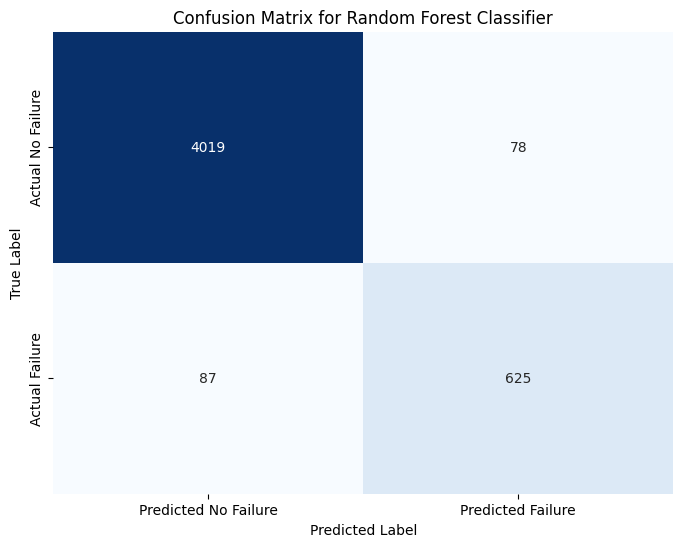

In [97]:
# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Failure', 'Predicted Failure'],
            yticklabels=['Actual No Failure', 'Actual Failure'])
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

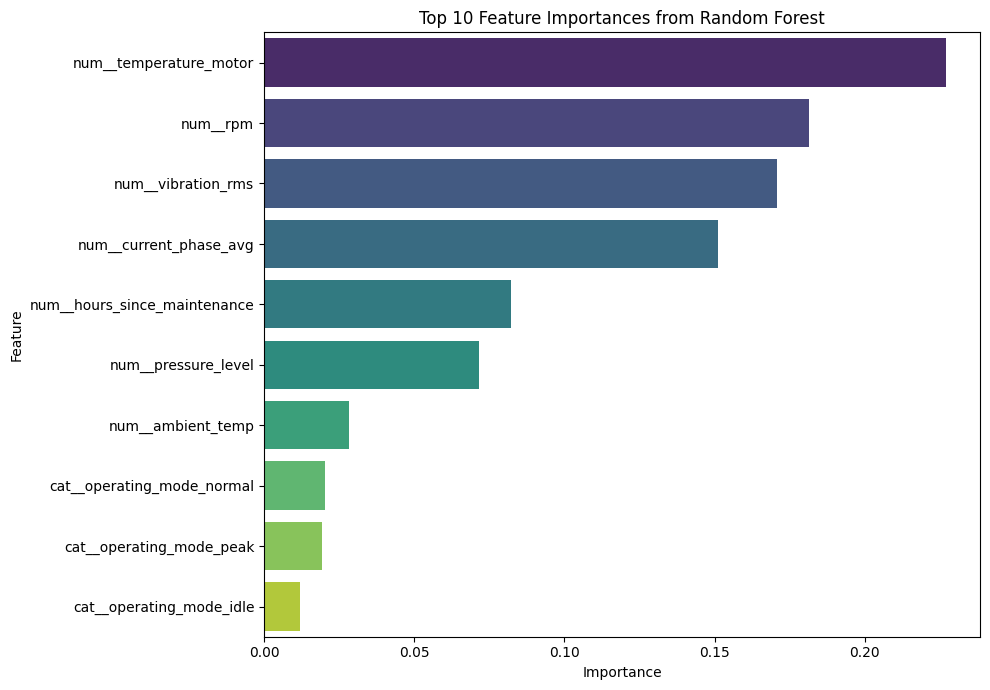

In [99]:
# Get feature names after one-hot encoding
encoded_feature_names = preprocessor.get_feature_names_out()

# Create a DataFrame for feature importances
feature_importances = pd.DataFrame({'Feature': encoded_feature_names, 'Importance': model.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Plot top 10 feature importances
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10), palette='viridis', hue='Feature', legend=False)
plt.title('Top 10 Feature Importances from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Business Interpretation & Conclusion

**Business Interpretation:** The Random Forest model demonstrates a good capability to predict machine failures within 24 hours, with an accuracy of approximately 96.5% and a solid F1-score for the failure class. This suggests it can be a valuable tool for proactive maintenance. The confusion matrix indicates that the model is reasonably effective at identifying actual failures while keeping false alarms manageable. Key features such as `temperature_motor`, `rpm`, and `vibration_rms` are identified as most important, reinforcing their critical role in machine health monitoring. Implementing this model can help maintenance teams prioritize interventions, reduce unplanned downtime, and optimize resource allocation.

**Conclusion:** This analysis highlights the potential of using machine learning to enhance predictive maintenance strategies. The Random Forest model provides a reliable method for early detection of potential failures, allowing for a shift from reactive to proactive maintenance. Future work could explore optimizing monitoring thresholds, integrating real-time data streams, and exploring the impact of more diverse failure data.